### Import necessary libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

### Read 'python logo.jpg' & 'opencv.png'

In [4]:
img1 = cv2.imread('python logo.jpg')
img2 = cv2.imread('opencv.png')

In [5]:
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

### View both the images

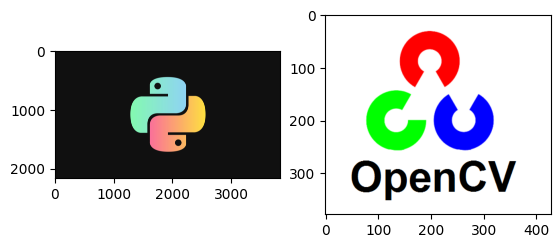

In [7]:
plt.subplot(1,2,1)
plt.imshow(img1)
plt.subplot(1,2,2)
plt.imshow(img2)

### Print the shape of both the images

In [9]:
print(f'Shape of Image 1 is {img1.shape}')
print(f'Shape of Image 2 is {img2.shape}')

Shape of Image 1 is (2160, 3840, 3)
Shape of Image 2 is (378, 428, 3)


### Set x and y offset to set the part where you want to paste the image

In [11]:
x_offset = 3840 - 428
y_offset = 2160 - 378

### Set the region of interest

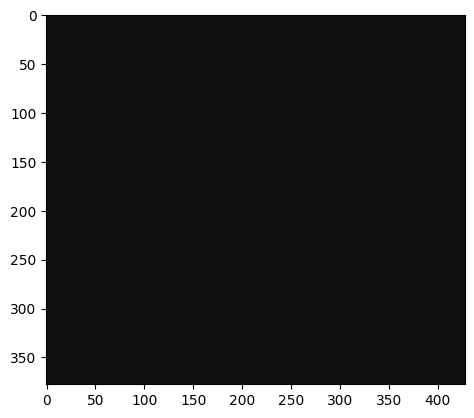

In [13]:
roi = img1[y_offset:2160, x_offset:3840]
plt.imshow(roi)

### Convert the smaller image into grayscale

In [15]:
img2gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

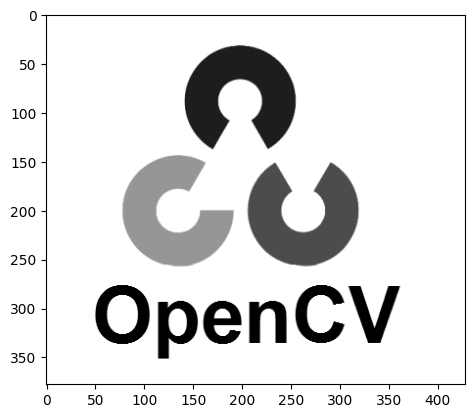

In [16]:
plt.imshow(img2gray, cmap = 'gray')

### Notice that letters in the image are not exactly colored in black but rather in some dark grey color. That is why we need to apply a thresholding in order to create a binary image.

In [18]:
ret,mask = cv2.threshold(img2gray, 150, 255, cv2.THRESH_BINARY)

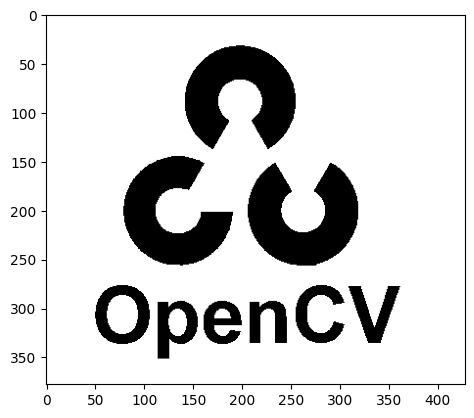

In [19]:
plt.imshow(mask, cmap = 'gray')

### Fetch the inverse of the image using 'bitwise_or'

Essentially just convert all black parts of the image to white and white parts to black

In [22]:
mask_inv = cv2.bitwise_not(mask)

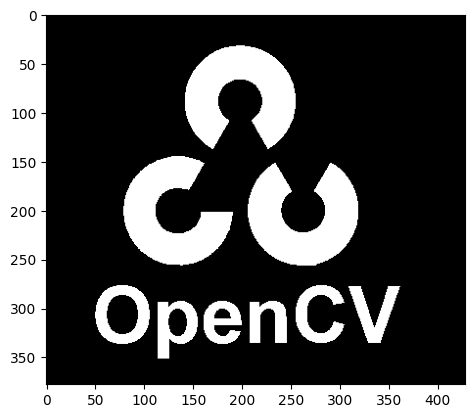

In [23]:
plt.imshow(mask_inv, cmap = 'gray')

### Paste the inverse mask on top of original image

In [25]:
fg = cv2.bitwise_or(img2,img2, mask = mask_inv)

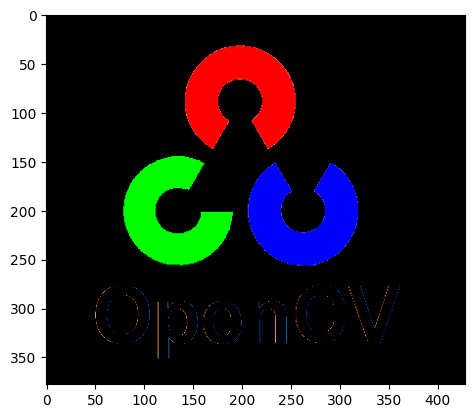

In [26]:
plt.imshow(fg)

### Paste the mask on top of our region of interest

In [28]:
bg = cv2.bitwise_or(roi,roi, mask = mask)

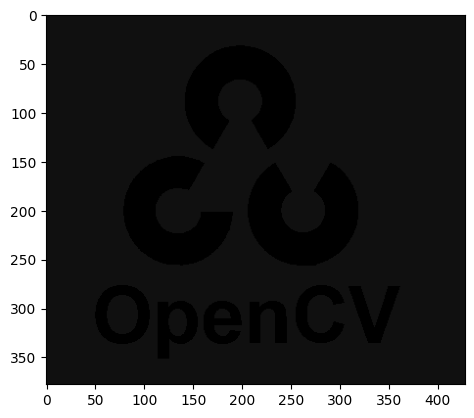

In [29]:
plt.imshow(bg)

### Add our foreground & background image

In [31]:
final_roi = cv2.add(fg,bg)

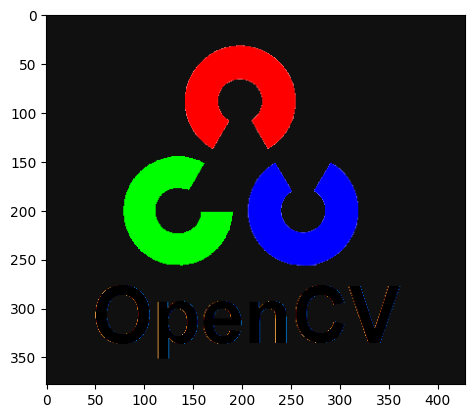

In [32]:
plt.imshow(final_roi)

### Paste the final roi on top of our original Image

In [34]:
img1[y_offset:2160,x_offset:3840] = final_roi

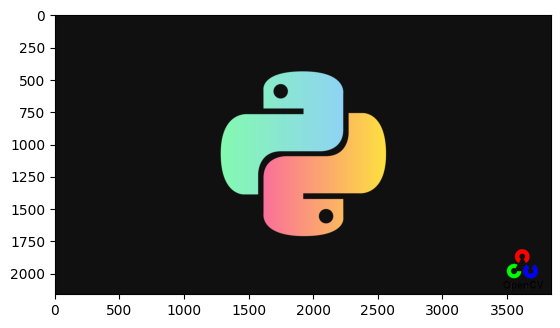

In [35]:
plt.imshow(img1)

***

# <center><a href = "http://edure.in/"><span style = "color:CornflowerBlue; font-family:Courier New;font-size:40px">EDURE LEARNING</span></a></center>